In [1]:
import pandas as pd

# If your file has data on the first sheet
df = pd.read_excel('E Commerce Dataset.xlsx')

# If your data is on a specific sheet, add sheet_name:
df = pd.read_excel('E Commerce Dataset.xlsx', sheet_name='E Comm')  # change 'Sheet1' to your actual sheet name

print(df.shape)
df.head()

(5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


# Data Cleaning

In [2]:
# 1. Check missing values
df.isnull().sum()

# 2. Fill or drop nulls (common for this dataset)
df.fillna(df.median(numeric_only=True), inplace=True)  # for numeric columns
df.fillna(df.mode().iloc[0], inplace=True)             # for categorical columns

# 3. Check for duplicates
df.duplicated().sum()
df.drop_duplicates(inplace=True)

# 4. Fix data types if needed
df.dtypes

# 5. Check for outliers in key columns
df[['Tenure', 'CashbackAmount', 'OrderCount']].describe()

,Tenure,CashbackAmount,OrderCount
count,5630.000000,5630.000000,5630.000000
mean,10.134103,177.223030,2.961812
std,8.357951,49.207036,2.879248
min,0.000000,0.000000,1.000000
25%,3.000000,145.770000,1.000000
50%,9.000000,163.280000,2.000000
75%,15.000000,196.392500,3.000000
max,61.000000,324.990000,16.000000


In [3]:
import pandas as pd
import numpy as np

# cleaning step 1: load the data
df = pd.read_excel('E Commerce Dataset.xlsx', sheet_name='E Comm')  
print("original shape:", df.shape)


# cleaning step 2: check missing values
print("\nMissing values:")
print(df.isnull().sum())

original shape: (5630, 20)

Missing values:
CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64


In [4]:
# cleaning step 3: Fix CustomerID — treat as string
df['CustomerID'] = df['CustomerID'].astype(str)

# cleaning step 4: Fill missing NUMERIC columns with median
numeric_cols = [
    'Tenure', 'WarehouseToHome', 'HourSpendOnApp',
    'OrderAmountHikeFromlastYear', 'CouponUsed',
    'OrderCount', 'DaySinceLastOrder', 'CashbackAmount'
]
for col in numeric_cols:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f" Filled {col} with median: {median_val}")

 Filled Tenure with median: 9.0
 Filled WarehouseToHome with median: 14.0
 Filled HourSpendOnApp with median: 3.0
 Filled OrderAmountHikeFromlastYear with median: 15.0
 Filled CouponUsed with median: 1.0
 Filled OrderCount with median: 2.0
 Filled DaySinceLastOrder with median: 3.0
 Filled CashbackAmount with median: 163.28


C:\Users\Admin\AppData\Local\Temp\ipykernel_16956\4210682798.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


In [5]:
# Step 5: Fill missing CATEGORICAL columns with mode
categorical_cols = [
    'PreferredLoginDevice', 'PreferredPaymentMode',
    'Gender', 'PreferedOrderCat', 'MaritalStatus'
]
for col in categorical_cols:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)
    print(f" Filled {col} with mode: {mode_val}")

 Filled PreferredLoginDevice with mode: Mobile Phone
 Filled PreferredPaymentMode with mode: Debit Card
 Filled Gender with mode: Male
 Filled PreferedOrderCat with mode: Laptop & Accessory
 Filled MaritalStatus with mode: Married


C:\Users\Admin\AppData\Local\Temp\ipykernel_16956\1144600474.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_val, inplace=True)


In [6]:
# Step 6: Drop duplicates
before = df.shape[0]
df.drop_duplicates(inplace=True)
print(f"\n Removed {before - df.shape[0]} duplicate rows")

# Step 7: Fix data types
df['Churn'] = df['Churn'].astype(int)
df['CityTier'] = df['CityTier'].astype(int)
df['SatisfactionScore'] = df['SatisfactionScore'].astype(int)
df['Complain'] = df['Complain'].astype(int)
df['NumberOfDeviceRegistered'] = df['NumberOfDeviceRegistered'].astype(int)
df['NumberOfAddress'] = df['NumberOfAddress'].astype(int)

# Step 8: Verify — no missing values remaining
print("\nMissing values after cleaning:")
print(df.isnull().sum())
print("\nFinal shape:", df.shape)


 Removed 0 duplicate rows

Missing values after cleaning:
CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

Final shape: (5630, 20)


In [73]:
# Count NaNs per column
print(df.isna().sum())

# Total NaNs in entire dataset
df.isna().sum().sum()

CustomerID                     0
Gender                         0
MaritalStatus                  0
CityTier                       0
Tenure                         0
NumberOfAddress                0
NumberOfDeviceRegistered       0
PreferredLoginDevice           0
PreferredPaymentMode           0
PreferedOrderCat               0
HourSpendOnApp                 0
SatisfactionScore              0
Complain                       0
OrderCount                     0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
CashbackAmount                 0
DaySinceLastOrder              0
WarehouseToHome                0
Churn                          0
dtype: int64


np.int64(0)

In [74]:
# splitting the file into 3 files
customers = df[['CustomerID', 'Gender', 'MaritalStatus', 'CityTier', 
                'Tenure', 'NumberOfAddress', 'NumberOfDeviceRegistered']].copy()

behavior = df[['CustomerID', 'PreferredLoginDevice', 'PreferredPaymentMode',
               'PreferedOrderCat', 'HourSpendOnApp', 
               'SatisfactionScore', 'Complain']].copy()

orders = df[['CustomerID', 'OrderCount', 'OrderAmountHikeFromlastYear',
             'CouponUsed', 'CashbackAmount', 
             'DaySinceLastOrder', 'WarehouseToHome', 'Churn']].copy()

customers.to_csv('customers.csv', index=False)
behavior.to_csv('behavior.csv', index=False)
orders.to_csv('orders.csv', index=False)

In [75]:
# Merge all 3 tables back together using CustomerID as the key
df = customers.merge(behavior, on='CustomerID').merge(orders, on='CustomerID')
df.to_csv('Ecommerce_cleaned.csv', index=False)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())



Shape: (5630, 20)
Columns: ['CustomerID', 'Gender', 'MaritalStatus', 'CityTier', 'Tenure', 'NumberOfAddress', 'NumberOfDeviceRegistered', 'PreferredLoginDevice', 'PreferredPaymentMode', 'PreferedOrderCat', 'HourSpendOnApp', 'SatisfactionScore', 'Complain', 'OrderCount', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'CashbackAmount', 'DaySinceLastOrder', 'WarehouseToHome', 'Churn']


In [76]:
df.head()

,CustomerID,Gender,MaritalStatus,CityTier,Tenure,NumberOfAddress,NumberOfDeviceRegistered,PreferredLoginDevice,PreferredPaymentMode,PreferedOrderCat,HourSpendOnApp,SatisfactionScore,Complain,OrderCount,OrderAmountHikeFromlastYear,CouponUsed,CashbackAmount,DaySinceLastOrder,WarehouseToHome,Churn
0,50001,Female,Single,3,4.0,9,3,Mobile Phone,Debit Card,Laptop & Accessory,3.0,2,1,1.0,11.0,1.0,159.93,5.0,6.0,1
1,50002,Male,Single,1,9.0,7,4,Phone,UPI,Mobile,3.0,3,1,1.0,15.0,0.0,120.90,0.0,8.0,1
2,50003,Male,Single,1,9.0,6,4,Phone,Debit Card,Mobile,2.0,3,1,1.0,14.0,0.0,120.28,3.0,30.0,1
3,50004,Male,Single,3,0.0,8,4,Phone,Debit Card,Laptop & Accessory,2.0,5,0,1.0,23.0,0.0,134.07,3.0,15.0,1
4,50005,Male,Single,1,0.0,3,3,Phone,CC,Mobile,3.0,5,0,1.0,11.0,1.0,129.60,3.0,12.0,1


# EDA 

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
## importing and loading data
# Settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

# Load cleaned merged dataframe (after cleaning + splitting + merging back)
df = pd.read_csv('Ecommerce.csv')
df['CustomerID'] = df['CustomerID'].astype(str)
print("Shape:", df.shape)
df.head()

Shape: (5630, 20)


,CustomerID,Gender,MaritalStatus,CityTier,Tenure,NumberOfAddress,NumberOfDeviceRegistered,PreferredLoginDevice,PreferredPaymentMode,PreferedOrderCat,HourSpendOnApp,SatisfactionScore,Complain,OrderCount,OrderAmountHikeFromlastYear,CouponUsed,CashbackAmount,DaySinceLastOrder,WarehouseToHome,Churn
0,50001,Female,Single,3,4.0,9,3,Mobile Phone,Debit Card,Laptop & Accessory,3.0,2,1,1.0,11.0,1.0,159.93,5.0,6.0,1
1,50002,Male,Single,1,9.0,7,4,Phone,UPI,Mobile,3.0,3,1,1.0,15.0,0.0,120.90,0.0,8.0,1
2,50003,Male,Single,1,9.0,6,4,Phone,Debit Card,Mobile,2.0,3,1,1.0,14.0,0.0,120.28,3.0,30.0,1
3,50004,Male,Single,3,0.0,8,4,Phone,Debit Card,Laptop & Accessory,2.0,5,0,1.0,23.0,0.0,134.07,3.0,15.0,1
4,50005,Male,Single,1,0.0,3,3,Phone,CC,Mobile,3.0,5,0,1.0,11.0,1.0,129.60,3.0,12.0,1


In [78]:
## statical summary
print("    NUMERIC SUMMARY ")
display(df.describe().round(2))

print("\n  CATEGORICAL SUMMARY ")
cat_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 
            'Gender', 'PreferedOrderCat', 'MaritalStatus']
for col in cat_cols:
    print(f"\n{col}:\n{df[col].value_counts()}")

    NUMERIC SUMMARY 


,CityTier,Tenure,NumberOfAddress,NumberOfDeviceRegistered,HourSpendOnApp,SatisfactionScore,Complain,OrderCount,OrderAmountHikeFromlastYear,CouponUsed,CashbackAmount,DaySinceLastOrder,WarehouseToHome,Churn
count,5630.00,5630.00,5630.00,5630.00,5630.00,5630.00,5630.00,5630.00,5630.00,5630.00,5630.00,5630.00,5630.00,5630.00
mean,1.65,10.12,4.21,3.69,2.93,3.07,0.28,2.52,15.67,1.44,175.32,4.43,15.53,0.17
std,0.92,8.29,2.56,1.02,0.70,1.38,0.45,1.71,3.58,1.07,44.07,3.44,8.09,0.37
min,1.00,0.00,1.00,1.00,0.50,1.00,0.00,1.00,11.00,0.00,69.84,0.00,5.00,0.00
25%,1.00,3.00,2.00,3.00,2.00,2.00,0.00,1.00,13.00,1.00,145.77,2.00,9.00,0.00
50%,1.00,9.00,3.00,4.00,3.00,3.00,0.00,2.00,15.00,1.00,163.28,3.00,14.00,0.00
75%,3.00,15.00,6.00,4.00,3.00,4.00,1.00,3.00,18.00,2.00,196.39,7.00,20.00,0.00
max,3.00,33.00,12.00,6.00,4.50,5.00,1.00,6.00,25.50,3.50,272.33,14.50,36.50,1.00



  CATEGORICAL SUMMARY 

PreferredLoginDevice:
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64

PreferredPaymentMode:
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64

Gender:
Gender
Male      3384
Female    2246
Name: count, dtype: int64

PreferedOrderCat:
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64

MaritalStatus:
MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64


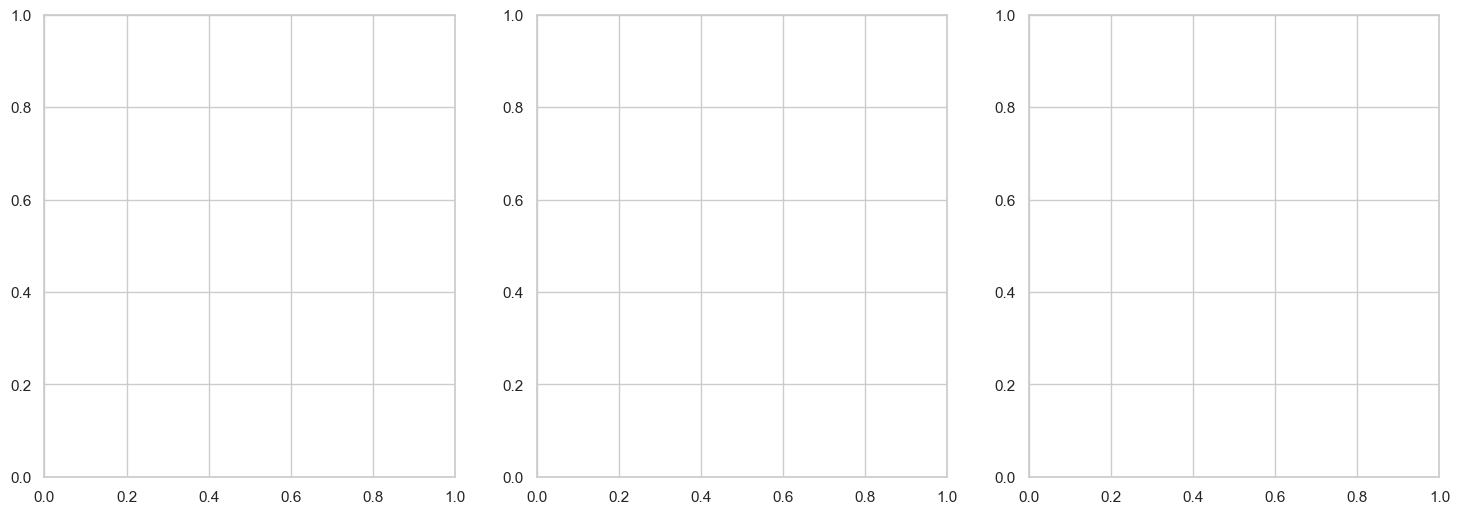

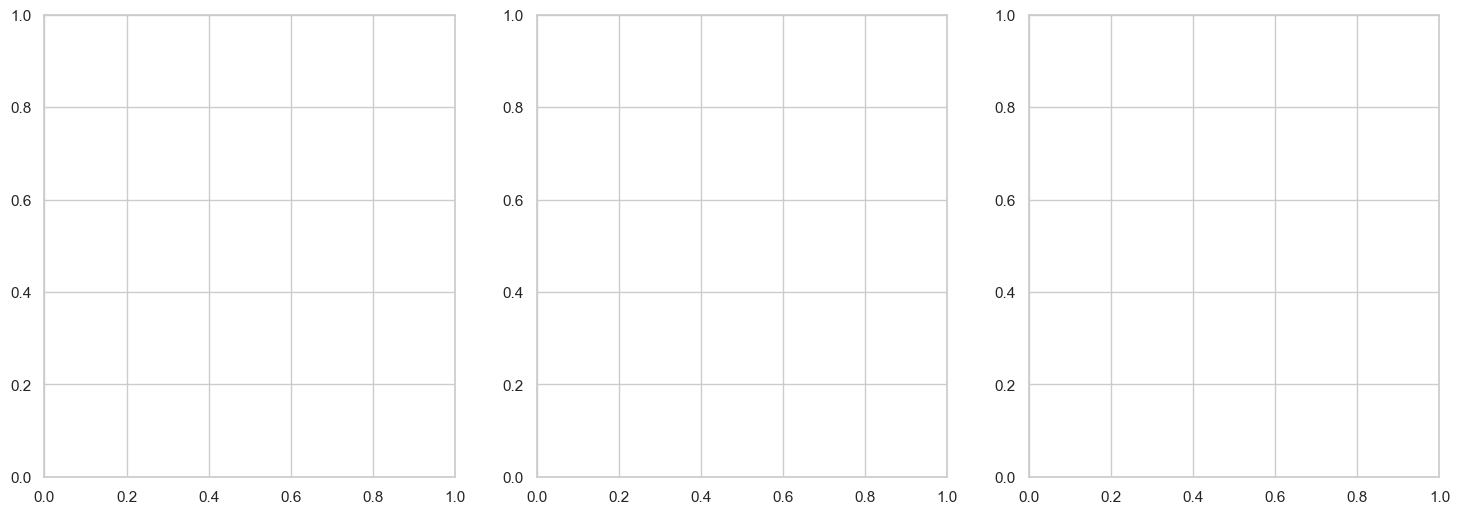

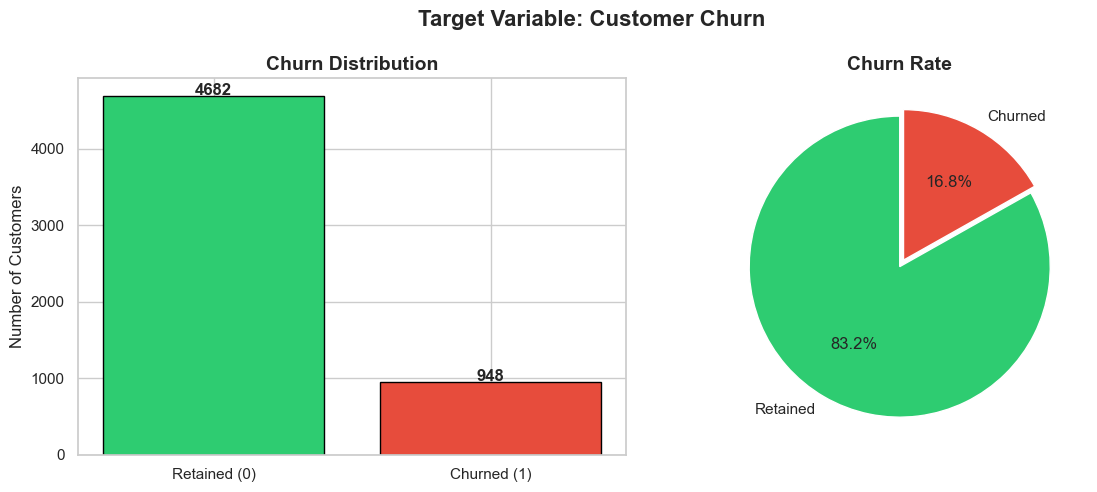

Churn Rate: 16.8%


In [79]:
## churn distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
churn_counts = df['Churn'].value_counts()
axes[0].bar(['Retained (0)', 'Churned (1)'], churn_counts.values, 
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Churn Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=['Retained', 'Churned'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0, 0.05))
axes[1].set_title('Churn Rate', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable: Customer Churn', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Churn Rate: {df['Churn'].mean()*100:.1f}%")

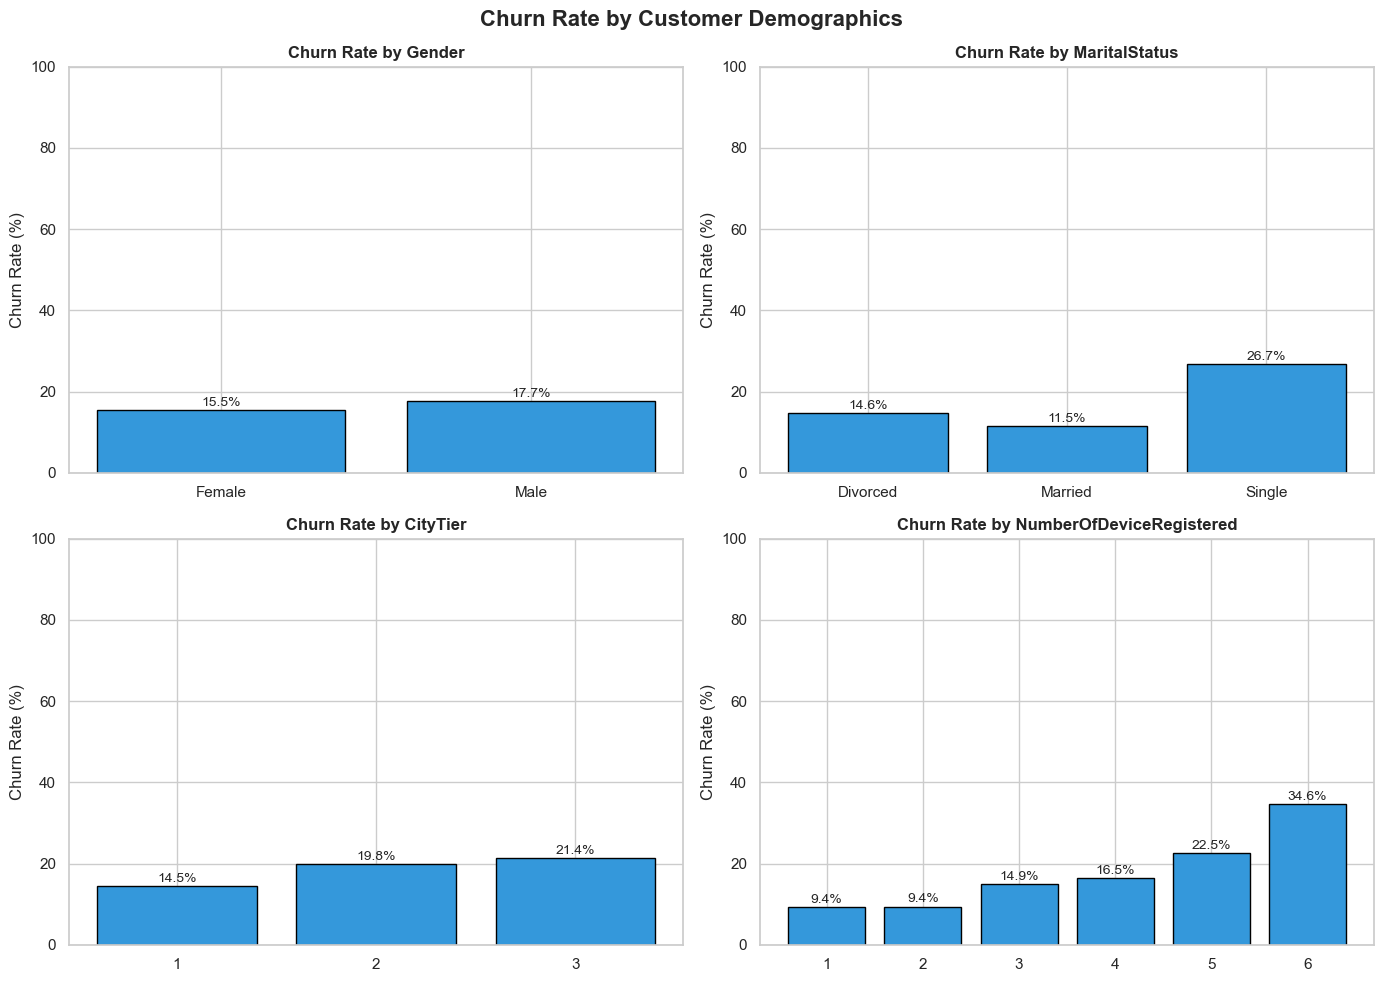

In [80]:
## chrun distribution by deographics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

demo_cols = ['Gender', 'MaritalStatus', 'CityTier', 'NumberOfDeviceRegistered']

for ax, col in zip(axes.flatten(), demo_cols):
    churn_rate = df.groupby(col)['Churn'].mean().reset_index()
    churn_rate['Churn'] = churn_rate['Churn'] * 100
    bars = ax.bar(churn_rate[col].astype(str), churn_rate['Churn'],
                  color='#3498db', edgecolor='black')
    ax.set_title(f'Churn Rate by {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, 100)
    for bar, val in zip(bars, churn_rate['Churn']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', fontsize=10)

plt.suptitle('Churn Rate by Customer Demographics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('churn_by_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

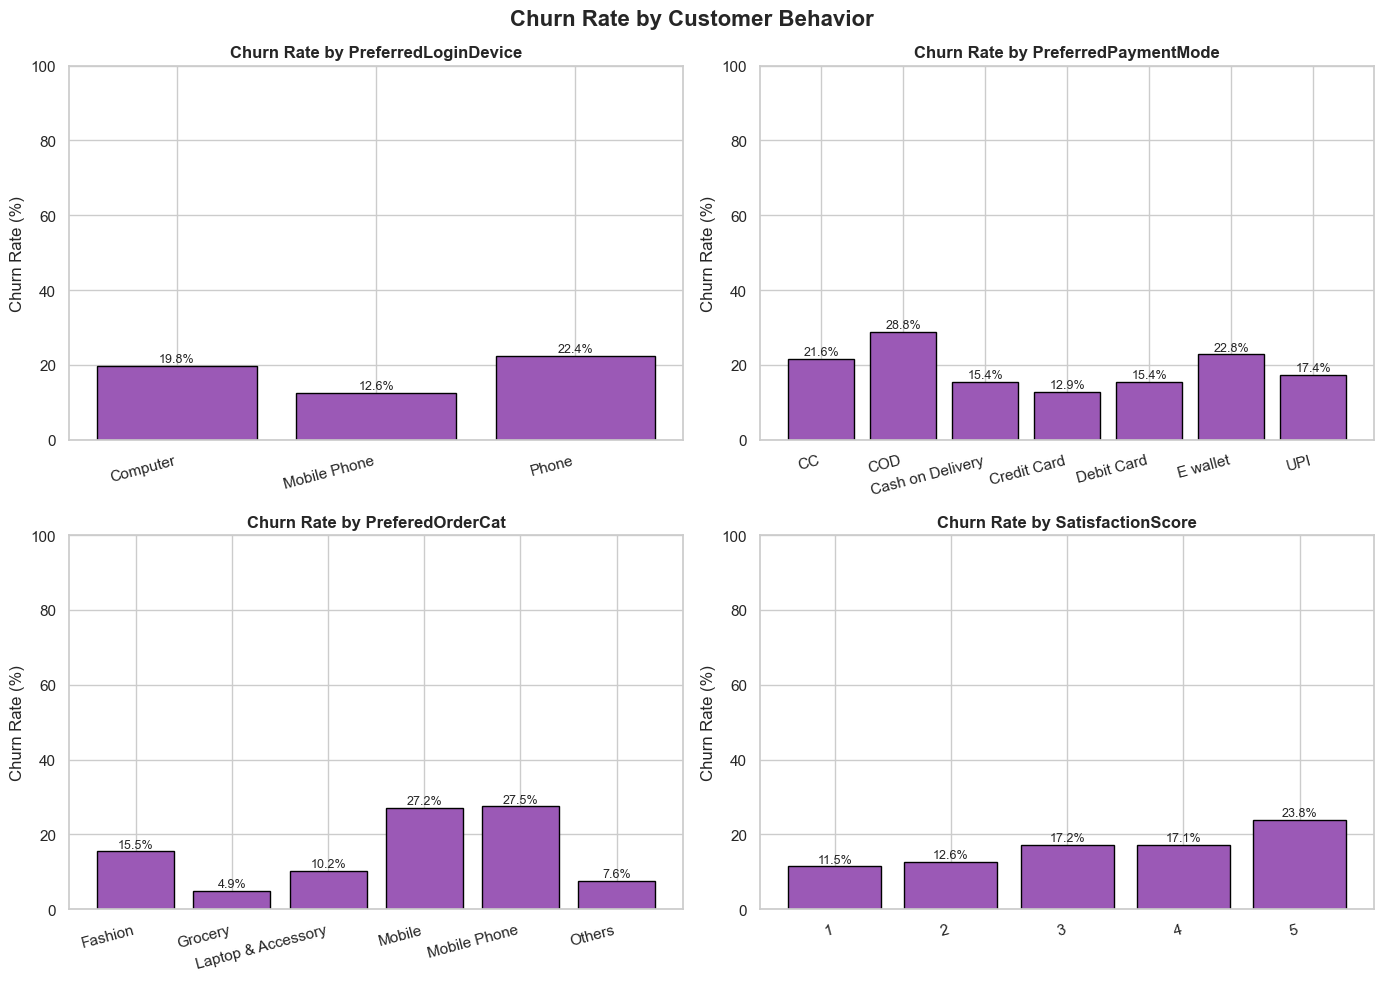

In [81]:
## churn by behavior
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

behavior_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 
                 'PreferedOrderCat', 'SatisfactionScore']

for ax, col in zip(axes.flatten(), behavior_cols):
    churn_rate = df.groupby(col)['Churn'].mean().reset_index()
    churn_rate['Churn'] = churn_rate['Churn'] * 100
    bars = ax.bar(churn_rate[col].astype(str), churn_rate['Churn'],
                  color='#9b59b6', edgecolor='black')
    ax.set_title(f'Churn Rate by {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, 100)
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right')
    for bar, val in zip(bars, churn_rate['Churn']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', fontsize=9)

plt.suptitle('Churn Rate by Customer Behavior', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('churn_by_behavior.png', dpi=150, bbox_inches='tight')
plt.show()

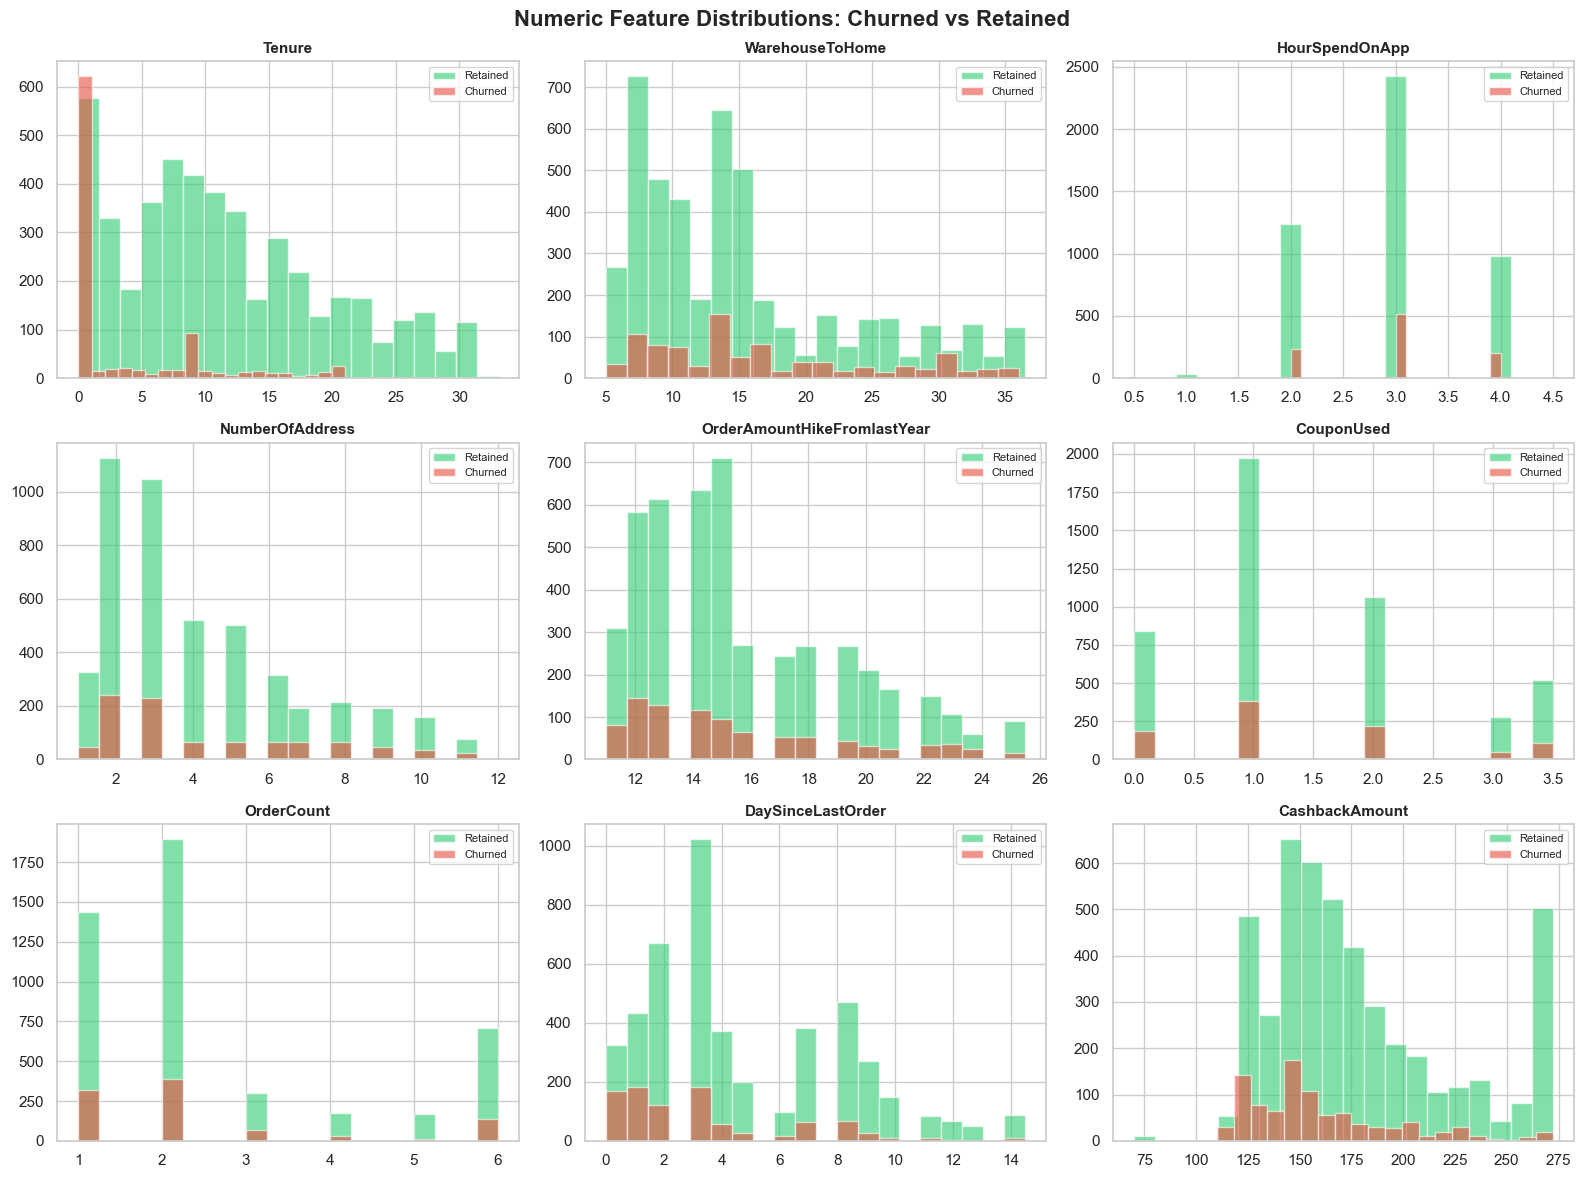

In [82]:
#numeric feature distribution
numeric_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
                'NumberOfAddress', 'OrderAmountHikeFromlastYear',
                'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for ax, col in zip(axes.flatten(), numeric_cols):
    # Overlay churned vs retained
    df[df['Churn']==0][col].hist(ax=ax, alpha=0.6, color='#2ecc71', 
                                  label='Retained', bins=20)
    df[df['Churn']==1][col].hist(ax=ax, alpha=0.6, color='#e74c3c', 
                                  label='Churned', bins=20)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Numeric Feature Distributions: Churned vs Retained', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

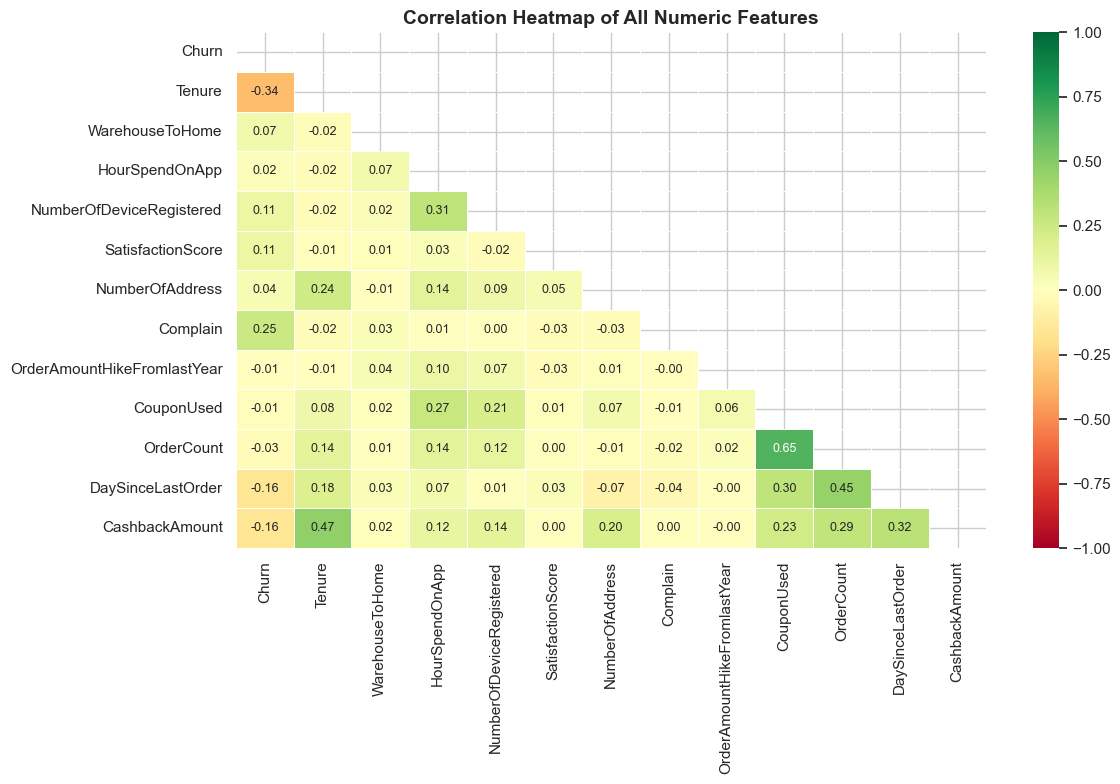

=== Top Correlations with Churn ===
Churn                          1.000
Complain                       0.250
NumberOfDeviceRegistered       0.108
SatisfactionScore              0.105
WarehouseToHome                0.074
NumberOfAddress                0.043
HourSpendOnApp                 0.019
OrderAmountHikeFromlastYear   -0.007
CouponUsed                    -0.009
OrderCount                    -0.030
CashbackAmount                -0.160
DaySinceLastOrder             -0.163
Tenure                        -0.340
Name: Churn, dtype: float64


In [83]:
## correlation heatmap
plt.figure(figsize=(12, 8))

corr_cols = ['Churn', 'Tenure', 'WarehouseToHome', 'HourSpendOnApp',
             'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress',
             'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed',
             'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

corr_matrix = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size': 9})

plt.title('Correlation Heatmap of All Numeric Features', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top correlations with Churn
print("=== Top Correlations with Churn ===")
print(corr_matrix['Churn'].sort_values(ascending=False).round(3))

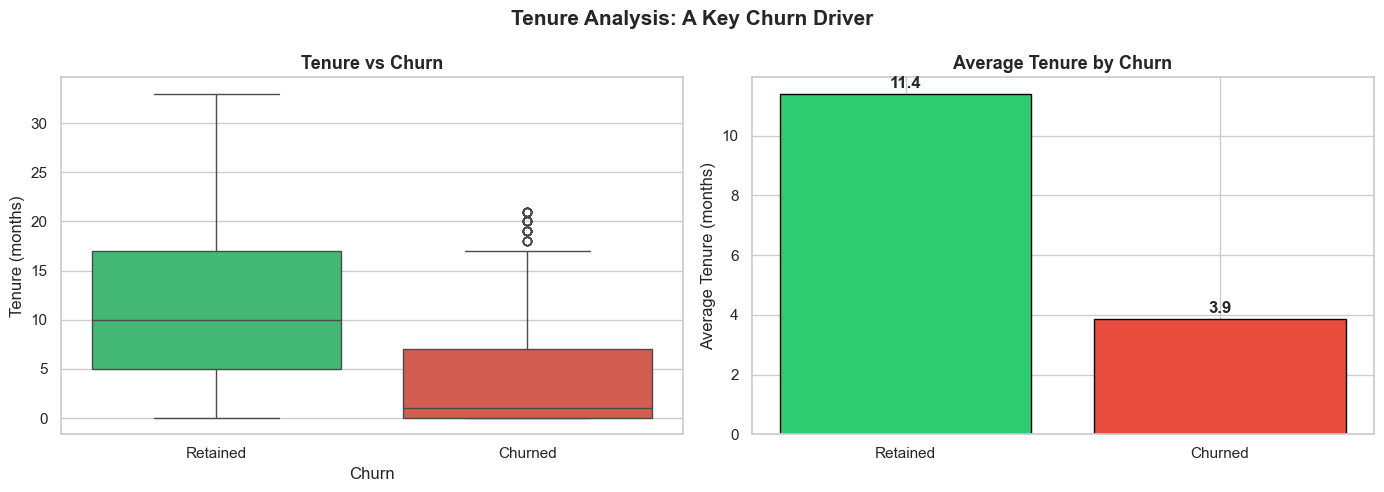

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Churn', y='Tenure',
            hue='Churn', palette=['#2ecc71', '#e74c3c'],
            legend=False, ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Retained', 'Churned'])
axes[0].set_title('Tenure vs Churn', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Tenure (months)')

avg_tenure = df.groupby('Churn')['Tenure'].mean()
axes[1].bar(['Retained', 'Churned'], avg_tenure.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_title('Average Tenure by Churn', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Tenure (months)')
for i, v in enumerate(avg_tenure.values):
    axes[1].text(i, v + 0.2, f'{v:.1f}', ha='center', fontweight='bold')

plt.suptitle('Tenure Analysis: A Key Churn Driver', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('tenure_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

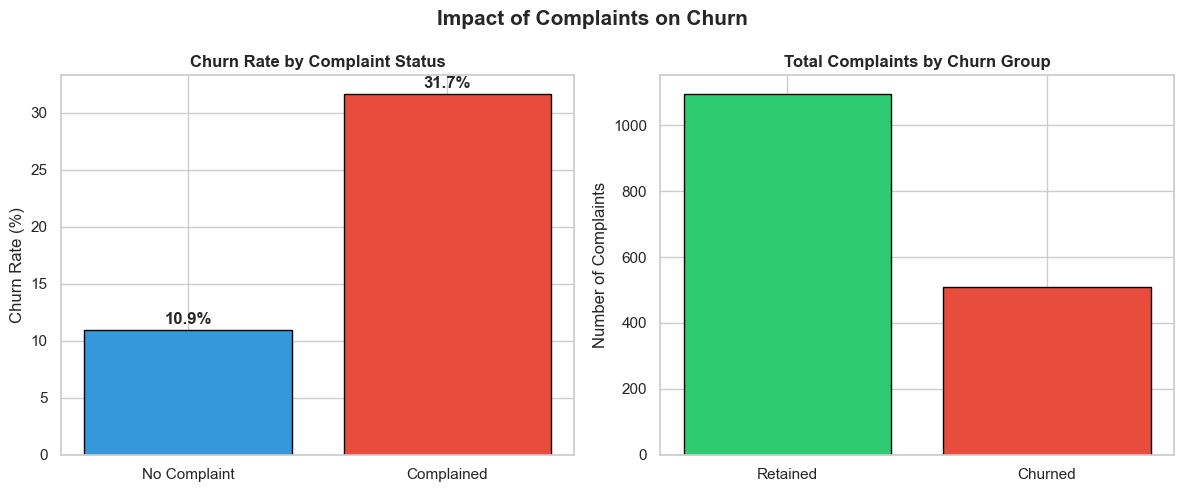

In [85]:
## complaints impact on chrun
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Churn rate by complaint
complain_churn = df.groupby('Complain')['Churn'].mean() * 100
axes[0].bar(['No Complaint', 'Complained'], complain_churn.values,
            color=['#3498db', '#e74c3c'], edgecolor='black')
axes[0].set_title('Churn Rate by Complaint Status', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(complain_churn.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Complaint count by churn
complain_count = df.groupby('Churn')['Complain'].sum()
axes[1].bar(['Retained', 'Churned'], complain_count.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_title('Total Complaints by Churn Group', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Complaints')

plt.suptitle('Impact of Complaints on Churn', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('complaints_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

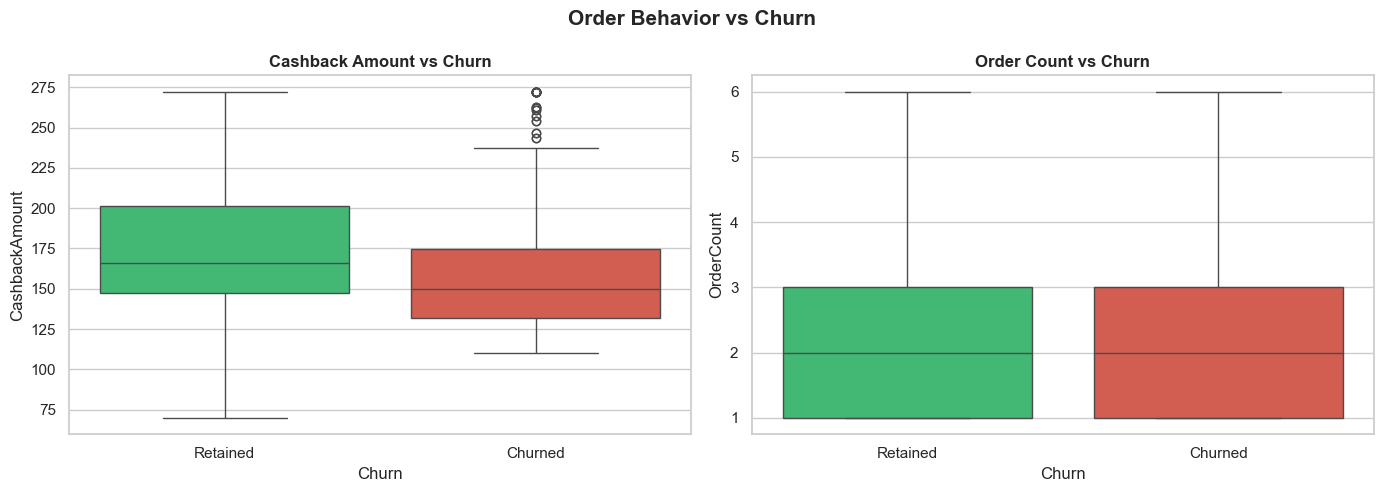

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Churn', y='CashbackAmount',
            hue='Churn', palette=['#2ecc71', '#e74c3c'],
            legend=False, ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Retained', 'Churned'])
axes[0].set_title('Cashback Amount vs Churn', fontsize=12, fontweight='bold')

sns.boxplot(data=df, x='Churn', y='OrderCount',
            hue='Churn', palette=['#2ecc71', '#e74c3c'],
            legend=False, ax=axes[1])
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Retained', 'Churned'])
axes[1].set_title('Order Count vs Churn', fontsize=12, fontweight='bold')

plt.suptitle('Order Behavior vs Churn', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('orders_cashback_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

In [87]:
print("=" * 55)
print("         EDA KEY INSIGHTS SUMMARY")
print("=" * 55)

print(f"\n Total Customers: {len(df):,}")
print(f" Churn Rate: {df['Churn'].mean()*100:.1f}%")
print(f" Retained Customers: {(df['Churn']==0).sum():,}")
print(f" Churned Customers: {(df['Churn']==1).sum():,}")

print(f"\n Avg Tenure (Retained): {df[df['Churn']==0]['Tenure'].mean():.1f} months")
print(f" Avg Tenure (Churned): {df[df['Churn']==1]['Tenure'].mean():.1f} months")

print(f"\n Complaint-Churn Rate: {df[df['Complain']==1]['Churn'].mean()*100:.1f}%")
print(f" No Complaint-Churn Rate: {df[df['Complain']==0]['Churn'].mean()*100:.1f}%")

print(f"\n Avg Cashback (Retained): ${df[df['Churn']==0]['CashbackAmount'].mean():.2f}")
print(f" Avg Cashback (Churned): ${df[df['Churn']==1]['CashbackAmount'].mean():.2f}")

print(f"\n Top Churn Category: {df[df['Churn']==1]['PreferedOrderCat'].mode()[0]}")
print(f" Top Payment Mode (Churned): {df[df['Churn']==1]['PreferredPaymentMode'].mode()[0]}")
print("=" * 55)

         EDA KEY INSIGHTS SUMMARY

 Total Customers: 5,630
 Churn Rate: 16.8%
 Retained Customers: 4,682
 Churned Customers: 948

 Avg Tenure (Retained): 11.4 months
 Avg Tenure (Churned): 3.9 months

 Complaint-Churn Rate: 31.7%
 No Complaint-Churn Rate: 10.9%

 Avg Cashback (Retained): $178.50
 Avg Cashback (Churned): $159.64

 Top Churn Category: Mobile Phone
 Top Payment Mode (Churned): Debit Card


## checking for outliers

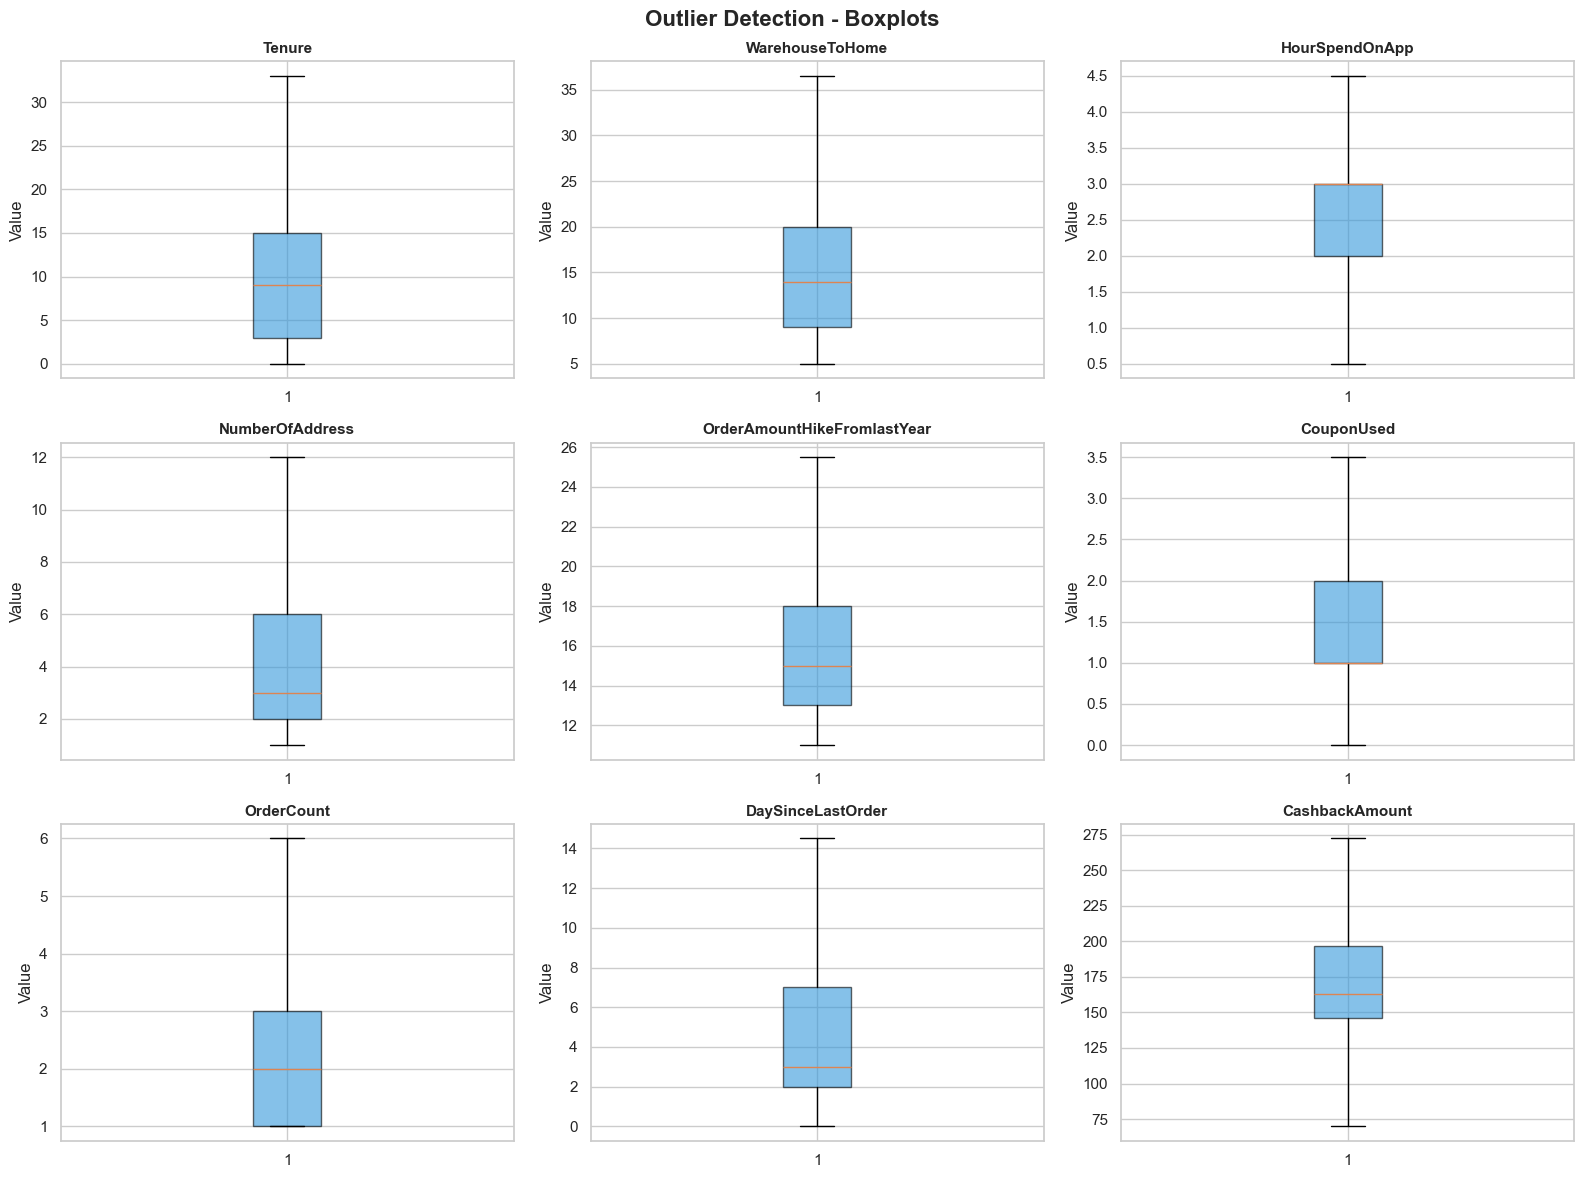

=== Outlier Counts (IQR Method) ===
Tenure: 0 outliers (0.0%)
WarehouseToHome: 0 outliers (0.0%)
HourSpendOnApp: 0 outliers (0.0%)
NumberOfAddress: 0 outliers (0.0%)
OrderAmountHikeFromlastYear: 0 outliers (0.0%)
CouponUsed: 0 outliers (0.0%)
OrderCount: 0 outliers (0.0%)
DaySinceLastOrder: 0 outliers (0.0%)
CashbackAmount: 0 outliers (0.0%)


In [88]:
# Outlier Detection using IQR
numeric_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
                'NumberOfAddress', 'OrderAmountHikeFromlastYear',
                'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for ax, col in zip(axes.flatten(), numeric_cols):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='#3498db', alpha=0.6))
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('Value')

plt.suptitle('Outlier Detection - Boxplots', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('outliers_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# Print outlier counts per column
print("=== Outlier Counts (IQR Method) ===")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")

In [89]:
# Cap outliers instead of removing them using IQR (Winsorization)
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

df.to_csv('Ecommerce.csv', index=False)
print("Shape after capping:", df.shape)


Shape after capping: (5630, 20)


## Feature Engineering

In [90]:
# Create new meaningful features from existing ones

# 1. Engagement Score — how active is the customer
df['EngagementScore'] = (df['HourSpendOnApp'] * df['OrderCount']) / (df['DaySinceLastOrder'] + 1)

# 2. Coupon Dependency — how much they rely on coupons
df['CouponDependency'] = df['CouponUsed'] / (df['OrderCount'] + 1)

# 3. Address Mobility — changing addresses often = less loyal
df['AddressMobility'] = df['NumberOfAddress'] / (df['Tenure'] + 1)

# 4. Cashback Per Order
df['CashbackPerOrder'] = df['CashbackAmount'] / (df['OrderCount'] + 1)

# 5. Is New Customer (Tenure less than 3 months)
df['IsNewCustomer'] = (df['Tenure'] <= 3).astype(int)


print("New shape:", df.shape)
print("\nNew columns added:")
new_cols = ['EngagementScore', 'CouponDependency', 
            'AddressMobility', 'CashbackPerOrder', 'IsNewCustomer']
print(df[new_cols].describe().round(3))

New shape: (5630, 25)

New columns added:
       EngagementScore  CouponDependency  AddressMobility  CashbackPerOrder  \
count         5630.000          5630.000         5630.000          5630.000   
mean             1.766             0.398            0.854            57.916   
std              1.353             0.247            1.249            22.295   
min              0.100             0.000            0.029             9.977   
25%              0.750             0.250            0.214            41.500   
50%              1.500             0.500            0.400            57.628   
75%              2.250             0.500            1.000            71.430   
max             18.000             1.167           10.000           136.163   

       IsNewCustomer  
count       5630.000  
mean           0.277  
std            0.448  
min            0.000  
25%            0.000  
50%            0.000  
75%            1.000  
max            1.000  


In [91]:
# One-hot encode categorical columns
cat_cols = ['PreferredLoginDevice', 'PreferredPaymentMode',
            'PreferedOrderCat', 'Gender', 'MaritalStatus']

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=False)

# Drop CustomerID (not needed for modeling)
df_encoded = df_encoded.drop(columns=['CustomerID'])


print("Shape after encoding:", df_encoded.shape)
print("\nAll columns:")
print(df_encoded.columns.tolist())

Shape after encoding: (5630, 40)

All columns:
['CityTier', 'Tenure', 'NumberOfAddress', 'NumberOfDeviceRegistered', 'HourSpendOnApp', 'SatisfactionScore', 'Complain', 'OrderCount', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'CashbackAmount', 'DaySinceLastOrder', 'WarehouseToHome', 'Churn', 'EngagementScore', 'CouponDependency', 'AddressMobility', 'CashbackPerOrder', 'IsNewCustomer', 'PreferredLoginDevice_Computer', 'PreferredLoginDevice_Mobile Phone', 'PreferredLoginDevice_Phone', 'PreferredPaymentMode_CC', 'PreferredPaymentMode_COD', 'PreferredPaymentMode_Cash on Delivery', 'PreferredPaymentMode_Credit Card', 'PreferredPaymentMode_Debit Card', 'PreferredPaymentMode_E wallet', 'PreferredPaymentMode_UPI', 'PreferedOrderCat_Fashion', 'PreferedOrderCat_Grocery', 'PreferedOrderCat_Laptop & Accessory', 'PreferedOrderCat_Mobile', 'PreferedOrderCat_Mobile Phone', 'PreferedOrderCat_Others', 'Gender_Female', 'Gender_Male', 'MaritalStatus_Divorced', 'MaritalStatus_Married', 'MaritalStatus_Sin

In [92]:
from sklearn.model_selection import train_test_split

# Target and features
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

print("Class distribution:")
print(y.value_counts())
print(f"\nChurn Rate: {y.mean()*100:.1f}%")

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n Train size: {X_train.shape}")
print(f" Test size: {X_test.shape}")

Class distribution:
Churn
0    4682
1     948
Name: count, dtype: int64

Churn Rate: 16.8%

 Train size: (4504, 39)
 Test size: (1126, 39)


In [93]:
## handeling class imbalance with SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_bal).value_counts().to_dict())
print(f"\n Balanced training set: {X_train_bal.shape}")

Before SMOTE: {0: 3746, 1: 758}
After SMOTE: {0: 3746, 1: 3746}

 Balanced training set: (7492, 39)


# Building the Model

In [94]:
!pip install xgboost imbalanced-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix,
                             roc_curve, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

print(" All libraries imported!")

 All libraries imported!


In [95]:
cat_cols = ['PreferredLoginDevice', 'PreferredPaymentMode',
            'PreferedOrderCat', 'Gender', 'MaritalStatus']

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=False)
df_encoded = df_encoded.drop(columns=['CustomerID'])

# Split features and target
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']


print("Features:", X.shape)
print("Target distribution:\n", y.value_counts())

Features: (5630, 39)
Target distribution:
 Churn
0    4682
1     948
Name: count, dtype: int64


In [96]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


In [97]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, 
                              eval_metric='logloss', verbosity=0)
}

# Train and evaluate each
results = {}
for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_prob)
    }
    

# Show comparison table
results_df = pd.DataFrame(results).T.round(4)
print("\n=== Model Comparison ===")
print(results_df)

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== Model Comparison ===
                     Accuracy  F1 Score     AUC
Logistic Regression    0.8748    0.6466  0.8865
Random Forest          0.9822    0.9468  0.9970
XGBoost                0.9885    0.9657  0.9983


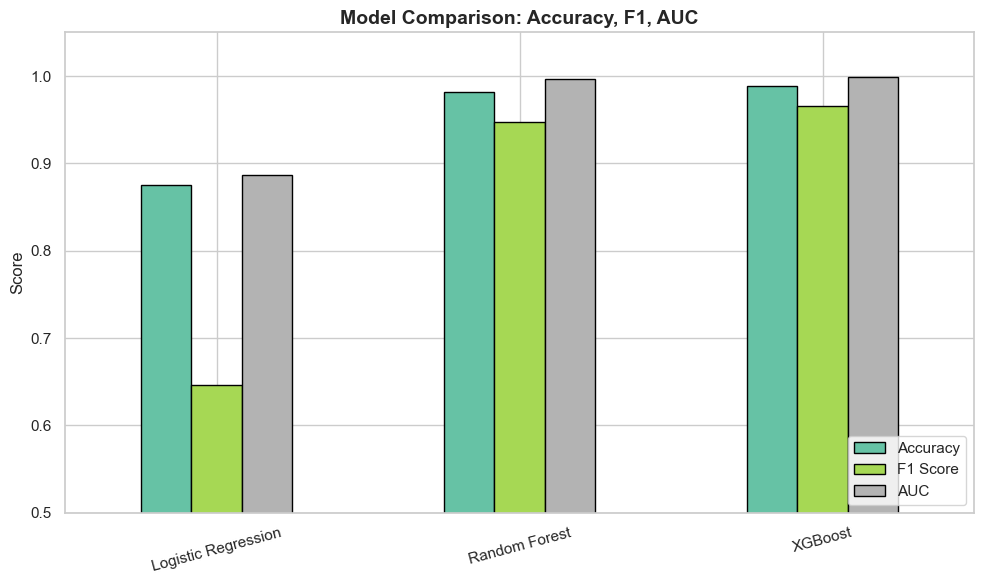

In [98]:
#models comparison
results_df.plot(kind='bar', figsize=(10, 6), colormap='Set2', edgecolor='black')
plt.title('Model Comparison: Accuracy, F1, AUC', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0.5, 1.05)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

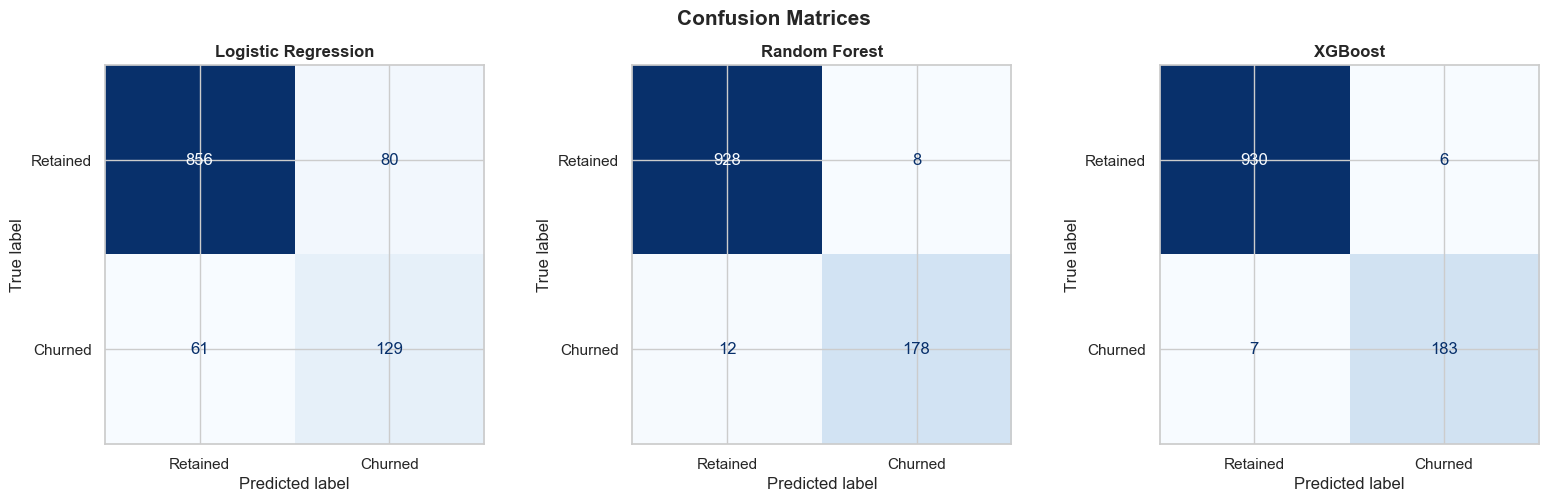

In [99]:
# plotting confusion matrice
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                   display_labels=['Retained', 'Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

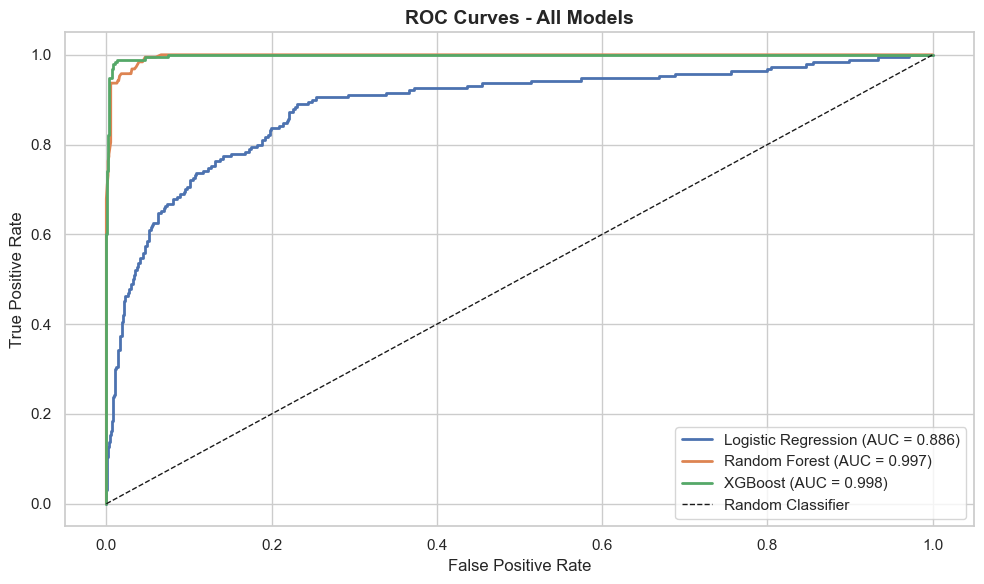

In [100]:
#plotting ROC curves
plt.figure(figsize=(10, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [101]:
# XGBoost detailed report
best_model = models['XGBoost']
y_pred = best_model.predict(X_test)

print("=== XGBoost Detailed Classification Report ===")
print(classification_report(y_test, y_pred, 
      target_names=['Retained', 'Churned']))

=== XGBoost Detailed Classification Report ===
              precision    recall  f1-score   support

    Retained       0.99      0.99      0.99       936
     Churned       0.97      0.96      0.97       190

    accuracy                           0.99      1126
   macro avg       0.98      0.98      0.98      1126
weighted avg       0.99      0.99      0.99      1126



# Explainability with SHAP

In [102]:
!pip install shap --quiet

import shap
print(" SHAP version:", shap.__version__)

 SHAP version: 0.51.0


In [103]:
# Use XGBoost model 
best_model = models['XGBoost']

# Create SHAP explainer
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values for test set
shap_values = explainer.shap_values(X_test)


print("Shape of SHAP values:", shap_values.shape)

Shape of SHAP values: (1126, 39)


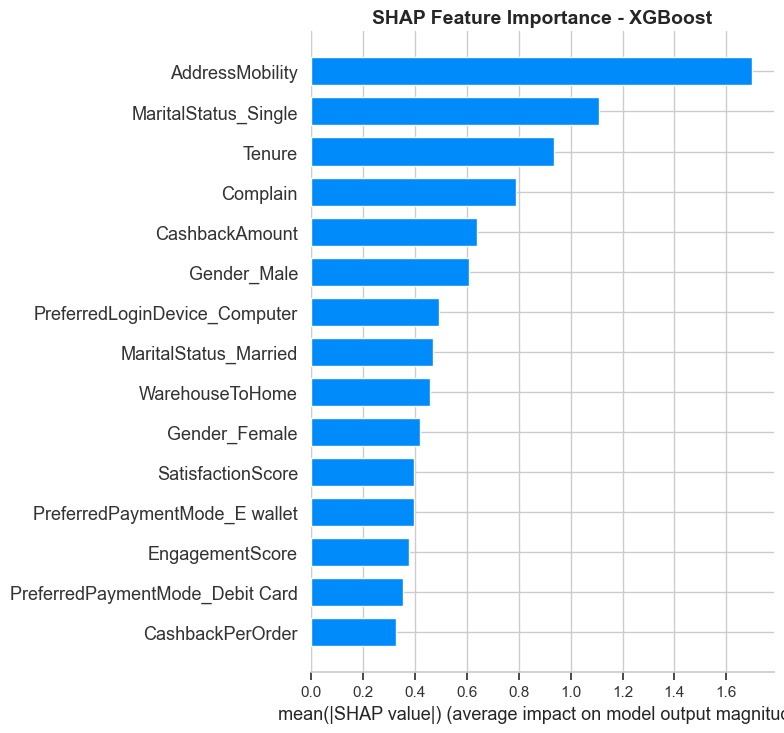

In [104]:
# SHAP feature importance 
plt.figure()
shap.summary_plot(
    shap_values, 
    X_test, 
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title('SHAP Feature Importance - XGBoost', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()


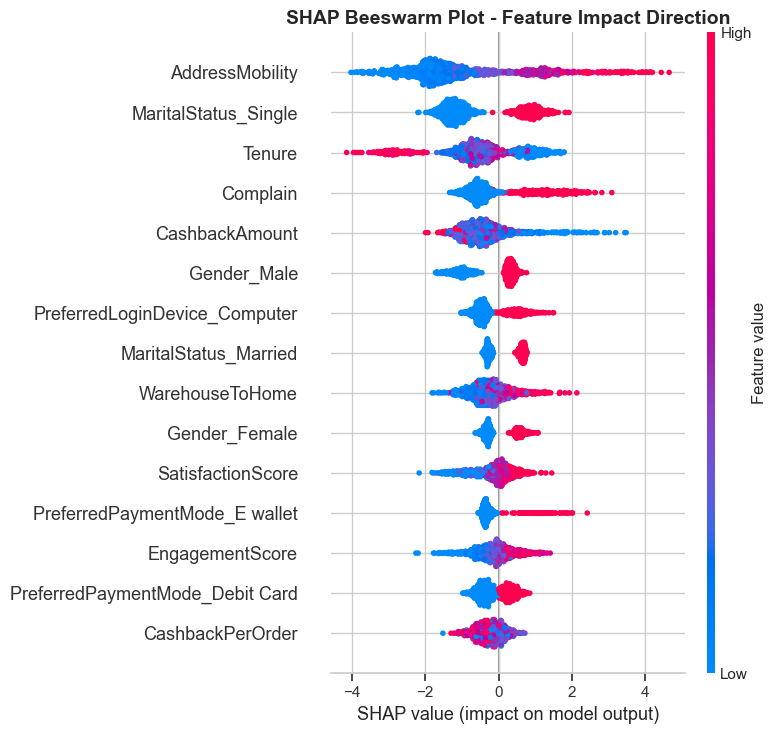

In [105]:
# plot showing HOW each feature impacts churn (positive = increases churn)
plt.figure()
shap.summary_plot(
    shap_values,
    X_test,
    max_display=15,
    show=False
)
plt.title('SHAP Beeswarm Plot - Feature Impact Direction',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

Top 3 features: ['AddressMobility', 'MaritalStatus_Single', 'Tenure']


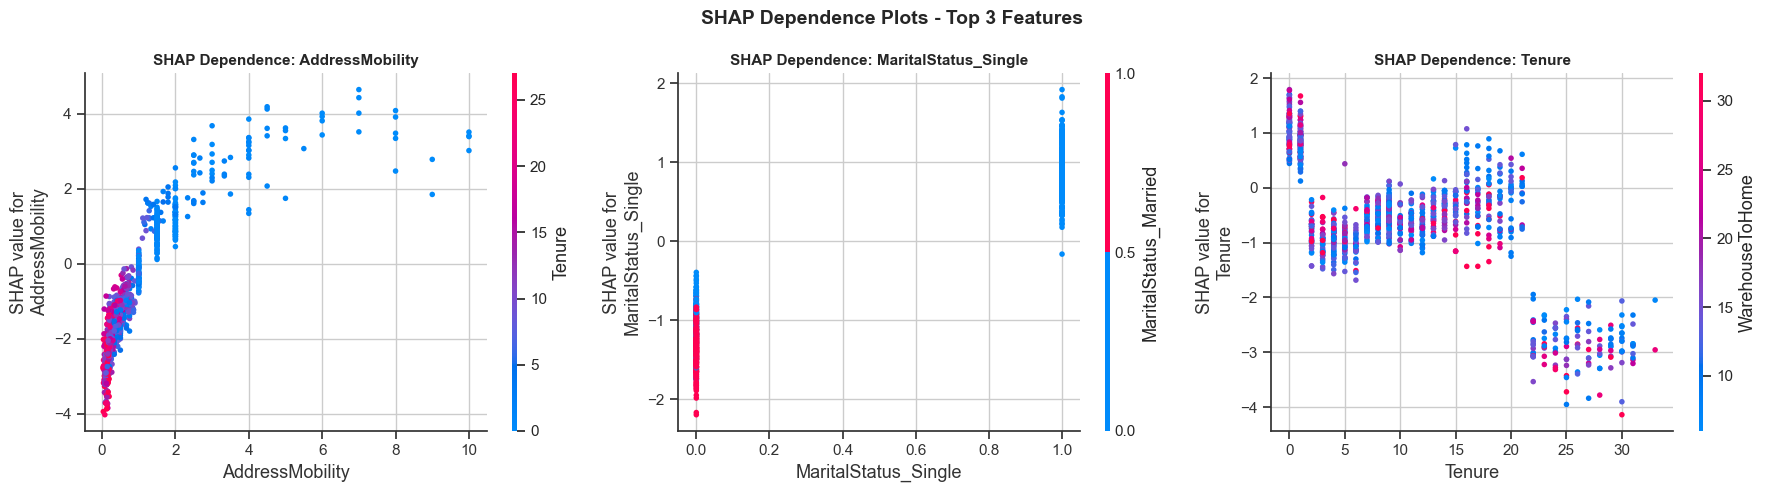

In [106]:
# Get top 3 most important features
top_features = pd.DataFrame({
    'feature': X_test.columns,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False).head(3)['feature'].tolist()

print("Top 3 features:", top_features)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, top_features):
    shap.dependence_plot(
        feature,
        shap_values,
        X_test,
        ax=ax,
        show=False
    )
    ax.set_title(f'SHAP Dependence: {feature}', 
                 fontsize=11, fontweight='bold')

plt.suptitle('SHAP Dependence Plots - Top 3 Features', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

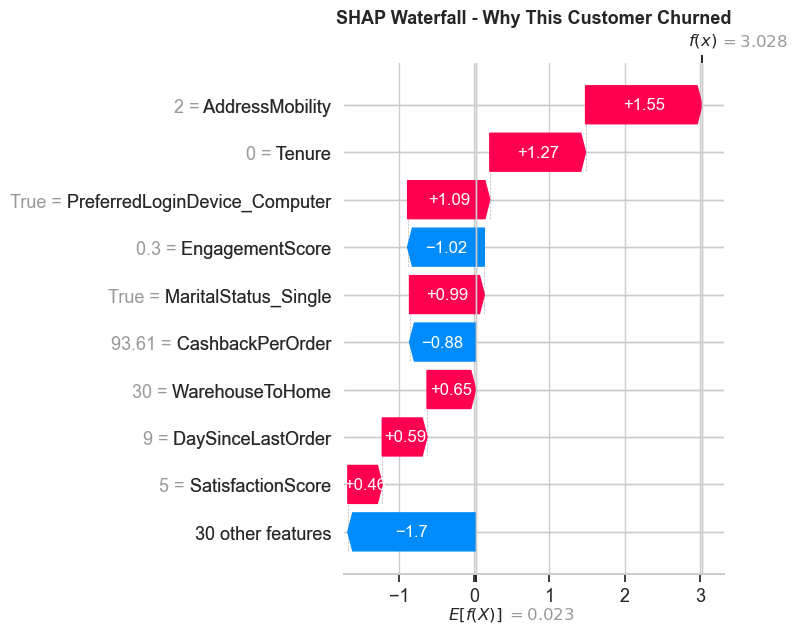

In [107]:
# Explaining one individual prediction 
churned_idx = y_test[y_test == 1].index[0]
churned_pos = X_test.index.get_loc(churned_idx)

plt.figure()
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[churned_pos],
        base_values=explainer.expected_value,
        data=X_test.iloc[churned_pos],
        feature_names=X_test.columns.tolist()
    ),
    show=False
)
plt.title('SHAP Waterfall - Why This Customer Churned',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()


In [108]:
print("        SHAP INSIGHTS SUMMARY")
shap_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean |SHAP|': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False).head(10)

print("\nTop 10 Features Driving Churn:\n")
for i, row in shap_importance.iterrows():
    print(f"  {shap_importance.index.get_loc(i)+1}. {row['Feature']:<40} {row['Mean |SHAP|']:.4f}")


        SHAP INSIGHTS SUMMARY

Top 10 Features Driving Churn:

  1. AddressMobility                          1.6988
  2. MaritalStatus_Single                     1.1095
  3. Tenure                                   0.9363
  4. Complain                                 0.7909
  5. CashbackAmount                           0.6401
  6. Gender_Male                              0.6098
  7. PreferredLoginDevice_Computer            0.4917
  8. MaritalStatus_Married                    0.4689
  9. WarehouseToHome                          0.4572
  10. Gender_Female                            0.4199


# Bias Analysis

In [109]:
!pip install fairlearn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate, false_negative_rate
from sklearn.metrics import accuracy_score, f1_score
print(" Fairlearn ready!")

 Fairlearn ready!


In [112]:
# Get test indices
test_indices = X_test.index

# Build bias df directly from original cleaned df
bias_df = df.loc[test_indices].copy()
bias_df['y_pred'] = best_model.predict(X_test)
bias_df['y_true'] = y_test.values

# Verify
print("Columns available:", bias_df.columns.tolist())
print("\nGender values:", bias_df['Gender'].value_counts().to_dict())
print("MaritalStatus values:", bias_df['MaritalStatus'].value_counts().to_dict())
print("CityTier values:", bias_df['CityTier'].value_counts().to_dict())
print("\nNull check:")
print(bias_df[['Gender', 'MaritalStatus', 'CityTier']].isnull().sum())

Columns available: ['CustomerID', 'Gender', 'MaritalStatus', 'CityTier', 'Tenure', 'NumberOfAddress', 'NumberOfDeviceRegistered', 'PreferredLoginDevice', 'PreferredPaymentMode', 'PreferedOrderCat', 'HourSpendOnApp', 'SatisfactionScore', 'Complain', 'OrderCount', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'CashbackAmount', 'DaySinceLastOrder', 'WarehouseToHome', 'Churn', 'EngagementScore', 'CouponDependency', 'AddressMobility', 'CashbackPerOrder', 'IsNewCustomer', 'y_pred', 'y_true']

Gender values: {'Male': 698, 'Female': 428}
MaritalStatus values: {'Married': 575, 'Single': 369, 'Divorced': 182}
CityTier values: {1: 759, 3: 324, 2: 43}

Null check:
Gender           0
MaritalStatus    0
CityTier         0
dtype: int64


In [123]:
from sklearn.metrics import accuracy_score, f1_score

def bias_metrics(df, group_col):
    results = []
    for group in df[group_col].unique():
        subset = df[df[group_col] == group]
        acc = accuracy_score(subset['y_true'], subset['y_pred'])
        f1 = f1_score(subset['y_true'], subset['y_pred'], zero_division=0)
        churn_rate = subset['y_pred'].mean()
        actual_churn = subset['y_true'].mean()
        results.append({
            'Group': group,
            'Count': len(subset),
            'Accuracy': round(acc, 4),
            'F1 Score': round(f1, 4),
            'Predicted Churn Rate': round(churn_rate, 4),
            'Actual Churn Rate': round(actual_churn, 4)
        })
    return pd.DataFrame(results).set_index('Group')

print("=" * 55)
print("       BIAS ANALYSIS RESULTS")
print("=" * 55)

print("\n Gender:")
gender_bias = bias_metrics(bias_df, 'Gender')
print(gender_bias)
print(f"Accuracy Difference: {gender_bias['Accuracy'].max() - gender_bias['Accuracy'].min():.4f}")

print("\n Marital Status:")
marital_bias = bias_metrics(bias_df, 'MaritalStatus')
print(marital_bias)
print(f"Accuracy Difference: {marital_bias['Accuracy'].max() - marital_bias['Accuracy'].min():.4f}")

print("\n City Tier:")
city_bias = bias_metrics(bias_df, 'CityTier')
print(city_bias)
print(f"Accuracy Difference: {city_bias['Accuracy'].max() - city_bias['Accuracy'].min():.4f}")

       BIAS ANALYSIS RESULTS

 Gender:
        Count  Accuracy  F1 Score  Predicted Churn Rate  Actual Churn Rate
Group                                                                     
Male      698     0.990    0.9712                0.1748             0.1734
Female    428     0.986    0.9559                0.1565             0.1612
Accuracy Difference: 0.0040

 Marital Status:
          Count  Accuracy  F1 Score  Predicted Churn Rate  Actual Churn Rate
Group                                                                       
Married     575    0.9878    0.9412                0.1043             0.1026
Single      369    0.9973    0.9950                0.2683             0.2710
Divorced    182    0.9725    0.9180                0.1648             0.1703
Accuracy Difference: 0.0248

 City Tier:
       Count  Accuracy  F1 Score  Predicted Churn Rate  Actual Churn Rate
Group                                                                    
3        324    0.9969    0.9917         

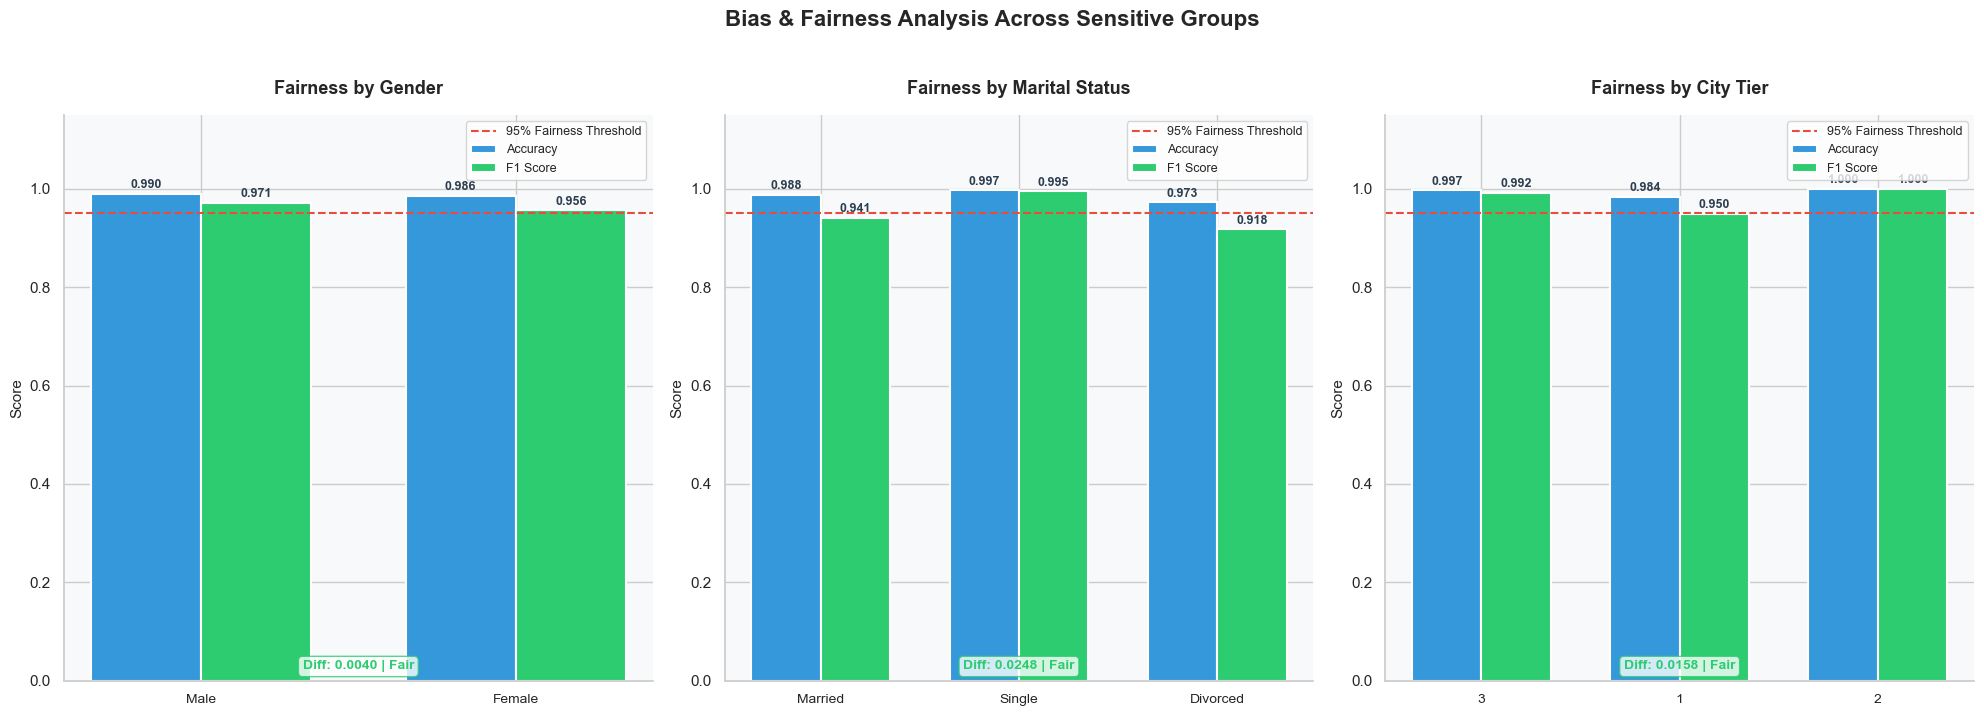

Bias visualization saved!


In [119]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']

for ax, (title, df_bias) in zip(axes, [
    ('Gender', gender_bias),
    ('Marital Status', marital_bias),
    ('City Tier', city_bias)
]):
    groups = df_bias.index.tolist()
    x = np.arange(len(groups))
    width = 0.35

    bars1 = ax.bar(x - width/2, df_bias['Accuracy'], width,
                   label='Accuracy', color='#3498db', 
                   edgecolor='white', linewidth=1.5)
    bars2 = ax.bar(x + width/2, df_bias['F1 Score'], width,
                   label='F1 Score', color='#2ecc71',
                   edgecolor='white', linewidth=1.5)

    # Add value labels on bars
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold', color='#2c3e50')
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold', color='#2c3e50')

    # Fairness threshold line
    ax.axhline(y=0.95, color='#e74c3c', linestyle='--',
               linewidth=1.5, label='95% Fairness Threshold')

    # Difference annotation
    diff = df_bias['Accuracy'].max() - df_bias['Accuracy'].min()
    status = "Fair" if diff < 0.05 else "Moderate Bias" if diff < 0.10 else "Significant Bias"
    color = '#2ecc71' if diff < 0.05 else '#f39c12' if diff < 0.10 else '#e74c3c'
    ax.text(0.5, 0.02, f'Diff: {diff:.4f} | {status}',
            transform=ax.transAxes, ha='center',
            fontsize=10, fontweight='bold', color=color,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                     edgecolor=color, alpha=0.8))

    ax.set_title(f'Fairness by {title}', fontsize=13, 
                 fontweight='bold', pad=15)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_ylim(0, 1.15)
    ax.set_xticks(x)
    ax.set_xticklabels(groups, fontsize=10)
    ax.legend(fontsize=9, loc='upper right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_facecolor('#f8f9fa')

fig.patch.set_facecolor('white')
plt.suptitle('Bias & Fairness Analysis Across Sensitive Groups',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('bias_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Bias visualization saved!")

In [122]:
print("=" * 55)
print("         BIAS ANALYSIS SUMMARY")
print("=" * 55)

groups = {
    'Gender': gender_bias,
    'Marital Status': marital_bias,
    'City Tier': city_bias
}

for name, df_bias in groups.items():
    diff = df_bias['Accuracy'].max() - df_bias['Accuracy'].min()
    if diff < 0.05:
        status = " Fair"
    elif diff < 0.10:
        status = "  Moderate Bias"
    else:
        status = " Significant Bias"
    print(f"\n{name}:")
    print(f"  Accuracy Difference: {diff:.4f}  =  {status}")


         BIAS ANALYSIS SUMMARY

Gender:
  Accuracy Difference: 0.0040  =   Fair

Marital Status:
  Accuracy Difference: 0.0248  =   Fair

City Tier:
  Accuracy Difference: 0.0158  =   Fair


# Deployment preparation

In [117]:
import joblib
import json

# Save the trained XGBoost model
joblib.dump(best_model, 'churn_model.pkl')

# Save feature names (needed for scoring)
feature_names = X_train.columns.tolist()
with open('feature_names.json', 'w') as f:
    json.dump(feature_names, f)

print(" Model saved: churn_model.pkl")
print(" Features saved: feature_names.json")
print(f" Number of features: {len(feature_names)}")

 Model saved: churn_model.pkl
 Features saved: feature_names.json
 Number of features: 39


In [121]:
# scoring script to a file
scoring_script = '''
import pandas as pd
import numpy as np
import joblib
import json

# === Load model and features ========
model = joblib.load('churn_model.pkl')

with open('feature_names.json', 'r') as f:
    feature_names = json.load(f)

#=== Preprocessing function ====
def preprocess(data):
    """
    Takes raw customer data and prepares it for prediction.
    Input: dict or DataFrame
    Output: encoded DataFrame ready for model
    """
    df = pd.DataFrame([data]) if isinstance(data, dict) else data.copy()

    # Feature engineering
    df['EngagementScore'] = (df['HourSpendOnApp'] * df['OrderCount']) / (df['DaySinceLastOrder'] + 1)
    df['CouponDependency'] = df['CouponUsed'] / (df['OrderCount'] + 1)
    df['AddressMobility'] = df['NumberOfAddress'] / (df['Tenure'] + 1)
    df['CashbackPerOrder'] = df['CashbackAmount'] / (df['OrderCount'] + 1)
    df['IsNewCustomer'] = (df['Tenure'] <= 3).astype(int)

    # Encode categorical columns
    cat_cols = ['PreferredLoginDevice', 'PreferredPaymentMode',
                'PreferedOrderCat', 'Gender', 'MaritalStatus']
    df = pd.get_dummies(df, columns=cat_cols, drop_first=False)

    # Align columns with training features
    df = df.reindex(columns=feature_names, fill_value=0)

    return df

# === Scoring function ===
def score(data):
    """
    Main scoring function.
    Input: raw customer data (dict or DataFrame)
    Output: churn probability and prediction
    """
    processed = preprocess(data)
    probability = model.predict_proba(processed)[:, 1][0]
    prediction = model.predict(processed)[0]

    return {
        'churn_prediction': int(prediction),
        'churn_probability': round(float(probability), 4),
        'risk_level': 'High' if probability > 0.7 else 'Medium' if probability > 0.4 else 'Low'
    }

# === Test the scoring script ===
if __name__ == "__main__":
    # Example customer
    sample_customer = {
        'Tenure': 2,
        'CityTier': 1,
        'WarehouseToHome': 10,
        'HourSpendOnApp': 3,
        'NumberOfDeviceRegistered': 3,
        'SatisfactionScore': 2,
        'NumberOfAddress': 5,
        'Complain': 1,
        'OrderAmountHikeFromlastYear': 15,
        'CouponUsed': 2,
        'OrderCount': 2,
        'DaySinceLastOrder': 10,
        'CashbackAmount': 150,
        'PreferredLoginDevice': 'Mobile Phone',
        'PreferredPaymentMode': 'Debit Card',
        'PreferedOrderCat': 'Mobile',
        'Gender': 'Male',
        'MaritalStatus': 'Single'
    }

    result = score(sample_customer)
    print("=== Scoring Result ===")
    print(f"Prediction:   {'Churned' if result['churn_prediction'] == 1 else 'Retained'}")
    print(f"Probability:  {result['churn_probability']*100:.1f}%")
    print(f"Risk Level:   {result['risk_level']}")
'''

# Save scoring script
with open('scoring_script.py', 'w', encoding='utf-8') as f:
    f.write(scoring_script)

print("Scoring script saved!")

Scoring script saved!
